# IF3270 Machine Learning | Praktikum 3
# Convolutional Neural Network
## Klasifikasi Spesies Mamalia Laut: Lumba-lumba vs Paus

This notebook serves as a template for Praktikum 3. Please create a copy of this notebook to complete your work. You can edit or add more code blocks, markdown blocks, or new sections if needed.

Group Number: 15

Group Members:
- Muhammad Raihan Nazhim Oktana (13523021)
- Hanif Kalyana Aditya (13523041)

## Import Libraries

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device : {device}")
from google.colab import drive
import warnings
warnings.filterwarnings("ignore")

Using Device : cuda


## Import Dataset

In [ ]:
FILE_ID = "1qEqLcUKv5lusITPIuOJsVhXunZC74wwO"
ZIP_FILE_PATH = "/content/dataset.zip"
!gdown --id {FILE_ID} -O {ZIP_FILE_PATH}
!mkdir -p /content/dataset/
!unzip -q -o {ZIP_FILE_PATH} -d /content/dataset/
BASE_LOCAL_PATH = "/content/dataset/"
TRAIN_CSV = os.path.join(BASE_LOCAL_PATH , "train.csv")
TEST_CSV = os.path.join(BASE_LOCAL_PATH , "test.csv")
TRAIN_IMG_DIR = os.path.join(BASE_LOCAL_PATH , "train/")
TEST_IMG_DIR = os.path.join(BASE_LOCAL_PATH , "test/")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1qEqLcUKv5lusITPIuOJsVhXunZC74wwO
From (redirected): https://drive.google.com/uc?id=1qEqLcUKv5lusITPIuOJsVhXunZC74wwO&confirm=t&uuid=c1316478-d0ce-4416-a369-be6029dcc95f
To: /content/dataset.zip
100% 69.8M/69.8M [00:01<00:00, 67.0MB/s]


---
# 1. Exploratory Data Analysis (EDA)

EDA adalah fondasi dari setiap proyek machine learning yang baik. Pada tahap ini, Anda diminta menjawab minimal 3 pertanyaan analitis menggunakan visualisasi yang tepat, dilengkapi dengan insight yang bermakna untuk setiap temuan.

### 1.1 [Wajib] Distribusi Sampel per Kelas

**Pertanyaan:** Bagaimana distribusi jumlah sampel per kelas (Lumba-lumba vs Paus)? Apakah terdapat class imbalance yang dapat mempengaruhi bias model CNN Anda?

In [ ]:
# Load Train Labels & Basic Dataset Info
train_df = pd.read_csv(TRAIN_CSV)
file_mapping = {}
for (f) in (os.listdir(TRAIN_IMG_DIR)) :
    name , ext = os.path.splitext(f)
    file_mapping[name] = f
train_df["File_ID"] = train_df["File_ID"].map(file_mapping)
print(f"Training Samples : {len(train_df)}")
train_df.head()
print(f"Train Shape : {train_df.shape}")
train_df.info()
print(train_df["Label"].value_counts())

Training Samples : 138
Train Shape : (138, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   File_ID  138 non-null    object
 1   Label    138 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ KB
Label
0    72
1    66
Name: count, dtype: int64


In [ ]:
# Write your code here (e.g., bar plot of class distribution)
print(train_df["Label"].value_counts())
print(train_df["Label"].value_counts(normalize = True).round(3))

Label
0    72
1    66
Name: count, dtype: int64
Label
0    0.522
1    0.478
Name: proportion, dtype: float64


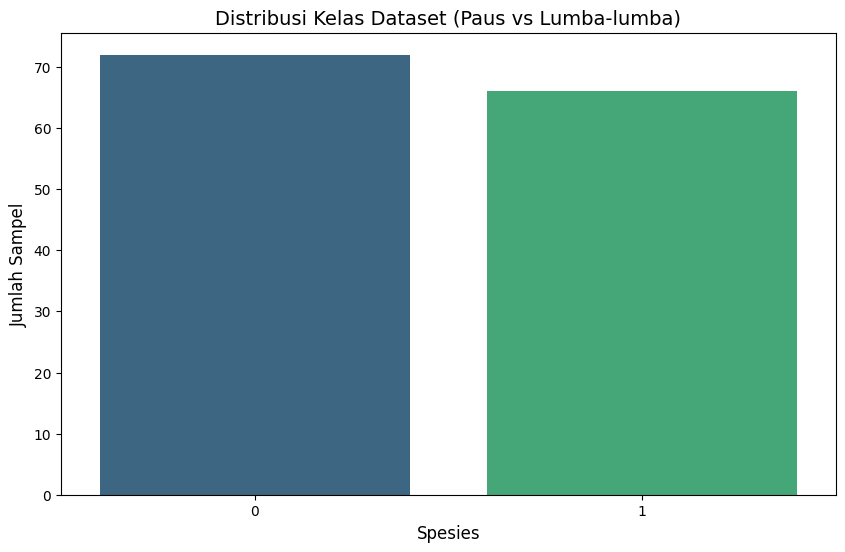

In [ ]:
plt.figure(figsize = (10 , 6))
ax = sns.countplot(data = train_df , x = "Label" , palette = "viridis")
total = len(train_df)
for (p) in (ax.patches) :
    percentage = f"{100 * p.get_height() / total:.1f}%"
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 10
    ax.annotate(percentage , (x , y) , size = 12)
plt.title("Distribusi Kelas Dataset (Paus vs Lumba-lumba)" , fontsize = 14)
plt.xlabel("Spesies" , fontsize = 12)
plt.ylabel("Jumlah Sampel" , fontsize = 12)
plt.show()

Secara umum, data setiap kelasnya cukup seimbang karena selisih keduanya hanya sekitar 5% saja, tidak terlalu besar sehingga kemungkinan untuk bias ke label yang lebih banyak (yaitu lumba-lumba sebanyak 72 gambar) tidak begitu besar.

(Data Lumba-lumba diberikan Label 0, dan Data Paus diberikan Label 1.)

### 1.2 [Wajib] Variasi Dimensi Gambar dan Aspect Ratio

**Pertanyaan:** Bagaimana variasi dimensi gambar (*width* dan *height*) serta *aspect ratio* pada dataset? Apakah diperlukan strategi *resizing* atau *padding* yang spesifik sebelum masuk ke arsitektur?

In [ ]:
# Write your code here
# Analyze image dimensions across the dataset
# Plot distributions of widths, heights, and aspect ratios
def get_dimensions(filename) :
    try :
        full_path = os.path.join(TRAIN_IMG_DIR , str(filename))
        with (Image.open(full_path)) as (img) :
            w , h = img.size
            return pd.Series([w , h , w / h])
    except (Exception) as e :
        print(f"Error di {filename} : {e}")
        return pd.Series([None , None , None])

train_dimension_df = train_df.copy()
train_dimension_df[["width" , "height" , "aspect_ratio"]] = train_dimension_df["File_ID"].apply(get_dimensions)
train_dimension_df = train_dimension_df.dropna(subset = ["width" , "height"])

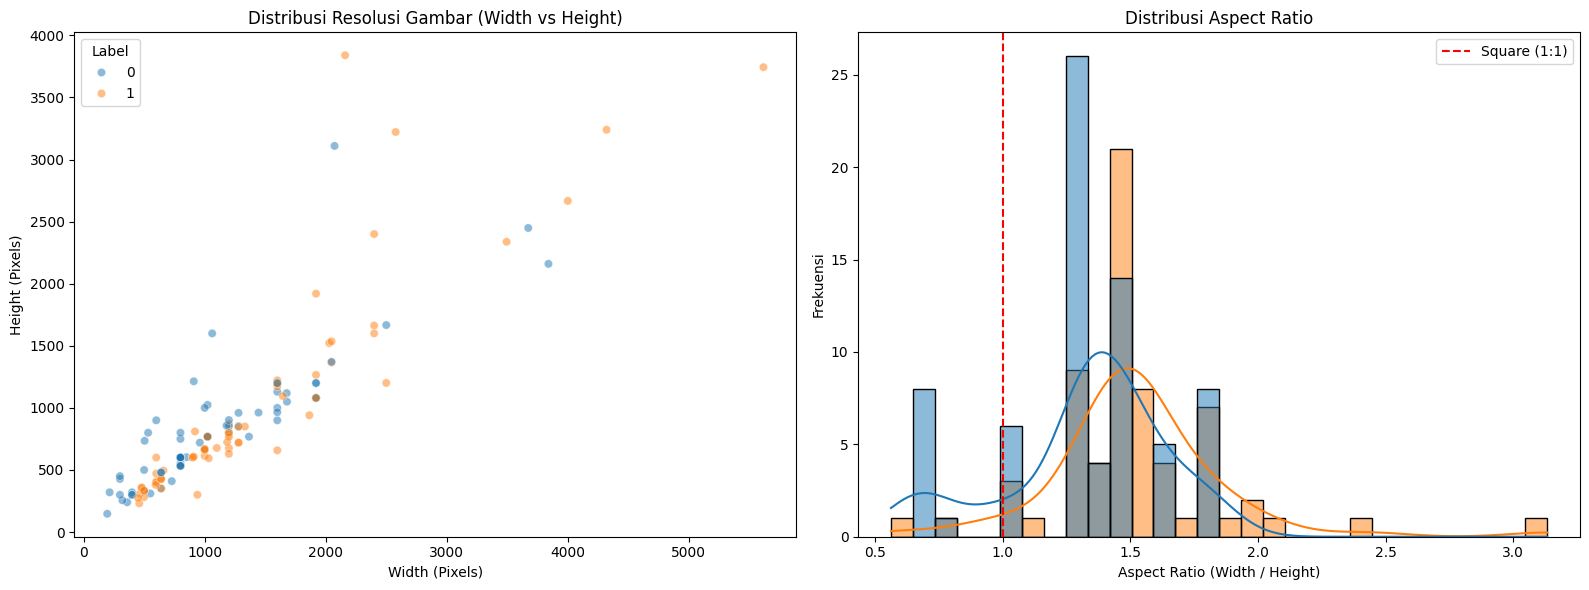

         width   height  aspect_ratio
count   138.00   138.00        138.00
mean   1233.14   903.83          1.42
std     852.62   679.56          0.34
min     195.00   147.00          0.56
25%     640.00   508.25          1.33
50%    1000.00   722.50          1.49
75%    1600.00  1080.00          1.52
max    5616.00  3840.00          3.13


In [ ]:
fig , axes = plt.subplots(1 , 2 , figsize = (16 , 6))
sns.scatterplot(data = train_dimension_df , x = "width" , y = "height" , hue = "Label" , alpha = 0.5 , ax = axes[0])
axes[0].set_title("Distribusi Resolusi Gambar (Width vs Height)")
axes[0].set_xlabel("Width (Pixels)")
axes[0].set_ylabel("Height (Pixels)")
sns.histplot(data = train_dimension_df , x = "aspect_ratio" , hue = "Label" , kde = True , bins = 30 , ax = axes[1])
axes[1].set_title("Distribusi Aspect Ratio")
axes[1].set_xlabel("Aspect Ratio (Width / Height)")
axes[1].set_ylabel("Frekuensi")
axes[1].axvline(1.0 , color = "red" , linestyle = "--" , label = "Square (1:1)")
axes[1].legend()
plt.tight_layout()
plt.show()
print(train_dimension_df[["width" , "height" , "aspect_ratio"]].describe().round(2))

Dari visualisasi tersebut, didapat fakta bahwa :

- Rata-rata ratio gambar adalah 1.42 atau dengan kata lain gambar berbentuk persegi panjang.
- Untuk kedua hewan, dilihat dari slope aspect ratio paus yang bergeser ke kanan dari milik lumba-lumba, dapat diartikan bentuk persegi panjang pada gambar paus cenderung lebih lonjong/panjang. hal ini wajar karena biasanya paus dalam kehidupan nyata memang lebih panjang secara ratio
- Mayoritas gambar berada dalam rentang (0 <= height <= 2000) dan (0 <= width <= 3000) untuk kedua hewan (label).

Untuk model AlexNet karena dibutuhkan dimensi 224x224, maka strategi yang paling aman adalah menambahkan padding dalam bentuk piksel hitam pada sisi yang lebih pendek dan diresize pada sisi yang lebih panjang di piksel ke 224

### 1.3 [Wajib] Distribusi Intensitas Nilai Piksel per Kelas

**Pertanyaan:** Bagaimana distribusi intensitas nilai piksel (R, G, B) untuk masing-masing kelas? Apakah terdapat perbedaan karakteristik warna yang **diskriminatif** untuk membedakan mamalia laut tersebut?

Mengambil 72 sampel untuk kelas 0
Mengambil 66 sampel untuk kelas 1


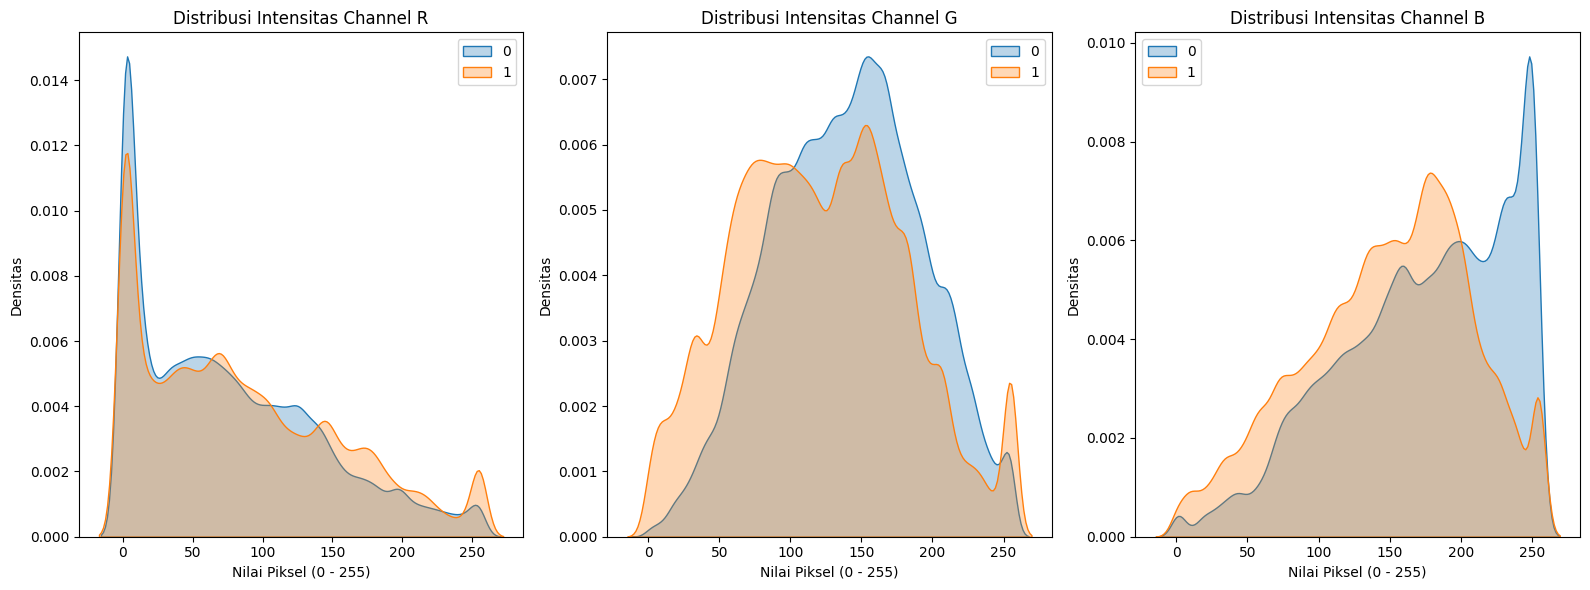

In [ ]:
# Write your code here
# Sample a subset of images from each class and compute average pixel intensities
# Plot histograms of R, G, B channels per class
def get_pixel_distributions(df , label_col = "Label" , path_col = "File_ID" , sample_size = 100) :
    labels = df[label_col].unique()
    rgb_data = {label : {"R" : [] , "G" : [] , "B" : []} for (label) in (labels)}
    for (label) in (labels) :
        class_data = df[df[label_col] == label][path_col].dropna()
        actual_sample_size = min(sample_size , len(class_data))
        print(f"Mengambil {actual_sample_size} sampel untuk kelas {label}")
        sample_paths = class_data.sample(n = actual_sample_size , random_state = SEED).values
        for (filename) in (sample_paths) :
            try :
                full_path = os.path.join(TRAIN_IMG_DIR , str(filename))
                img = Image.open(full_path).convert("RGB").resize((64 , 64))
                img_array = np.array(img)
                rgb_data[label]["R"].extend(img_array[:,:,0].flatten())
                rgb_data[label]["G"].extend(img_array[:,:,1].flatten())
                rgb_data[label]["B"].extend(img_array[:,:,2].flatten())
            except (Exception) as e :
                print(f"Gagal memproses {filename} : {e}")
    return (rgb_data , labels)

rgb_data , classes = get_pixel_distributions(train_df , sample_size = 100)
fig , axes = plt.subplots(1 , 3 , figsize = (16 , 6))
colors = ["red" , "green" , "blue"]
channels = ["R" , "G" , "B"]
for (i , (channel , color)) in (enumerate(zip(channels , colors))) :
    for (label) in (classes) :
        sns.kdeplot(rgb_data[label][channel] , label = label , ax = axes[i] , fill = True , alpha = 0.3)
    axes[i].set_title(f"Distribusi Intensitas Channel {channel}")
    axes[i].set_xlabel("Nilai Piksel (0 - 255)")
    axes[i].set_ylabel("Densitas")
    axes[i].legend()
plt.tight_layout()
plt.show()

Dari visualisasi distribusi densitas warna merah, hijau, dan biru, didapat fakta bahwa :

- Merah : Cenderung sama.
- Hijau : Pada rentang nilai piksel < 100, densitas warna cenderung lebih tinggi untuk paus dan sebaliknya lebih tinggi untuk lumba-lumba pada sisa rentang nilainya (100 - 250).
- Biru : Menariknya ada spike densitas pada rentang nilai piksel 200 - 250 untuk lumba-lumba dan berbanding terbalik untuk paus pada rentang nilai yang sama. pada rentang nilai inilah, perbedaan dapat sangat ditentukan.

Insightnya adalah pada rentang nilai piksel 200 - 250 warna biru, terdapat perbedaan densitas warna yang sangat kontras terutama pada sekitar nilai 245 - 250. maka fitur ini dapat dimanfaatkan model untuk menentukan perbedaan antara kedua hewan tersebut.

### 1.4 [Opsional] Analisis Tambahan

Pilih minimal 1 dari pertanyaan berikut:
- Apakah terdapat kemiripan visual yang tinggi antar kelas pada beberapa sampel tertentu? Apa implikasinya terhadap potensi *false positive* pada model?
- Bagaimana sebaran data gambar jika diproyeksikan ke dalam ruang 2D menggunakan metode reduksi dimensi (seperti PCA atau t-SNE)? Seberapa terpisah kedua kelas tersebut secara visual?
- Apakah terdapat outlier berupa gambar dengan kualitas rendah, noise berlebih, atau pencahayaan ekstrem? Bagaimana distribusinya per kelas?

**Pertanyaan yang dipilih:** Bagaimana sebaran data gambar jika diproyeksikan ke dalam ruang 2D menggunakan metode reduksi dimensi (seperti PCA atau t-SNE)? Seberapa terpisah kedua kelas tersebut secara visual?

In [ ]:
# Write your code here
def extract_features_for_tsne(df , label_col = "Label" , path_col = "File_ID") :
    labels = df[label_col].unique()
    features = []
    y_labels = []
    for (label) in (labels) :
        class_data = df[df[label_col] == label][path_col].dropna()
        actual_sample_size = len(class_data)
        print(f"Mengekstrak {actual_sample_size} gambar untuk kelas {label}")
        sample_paths = class_data.sample(n = actual_sample_size , random_state = SEED).values
        for (filename) in (sample_paths) :
            try :
                full_path = os.path.join(TRAIN_IMG_DIR , str(filename))
                img = Image.open(full_path).convert("L").resize((64 , 64))
                img_array = np.array(img).flatten()
                features.append(img_array)
                y_labels.append(label)
            except (Exception) as e :
                pass
    return (np.array(features) , np.array(y_labels))

X_features , y_labels = extract_features_for_tsne(train_df , path_col = "File_ID")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca = PCA(n_components = 50 , random_state = SEED)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components = 2 , perplexity = 30 , random_state = SEED)
X_tsne = tsne.fit_transform(X_pca)
tsne_df = pd.DataFrame({"t-SNE Dimensi 1" : X_tsne[:,0] ,
                        "t-SNE Dimensi 2" : X_tsne[:,1] ,
                        "Label" : y_labels})

Mengekstrak 72 gambar untuk kelas 0
Mengekstrak 66 gambar untuk kelas 1


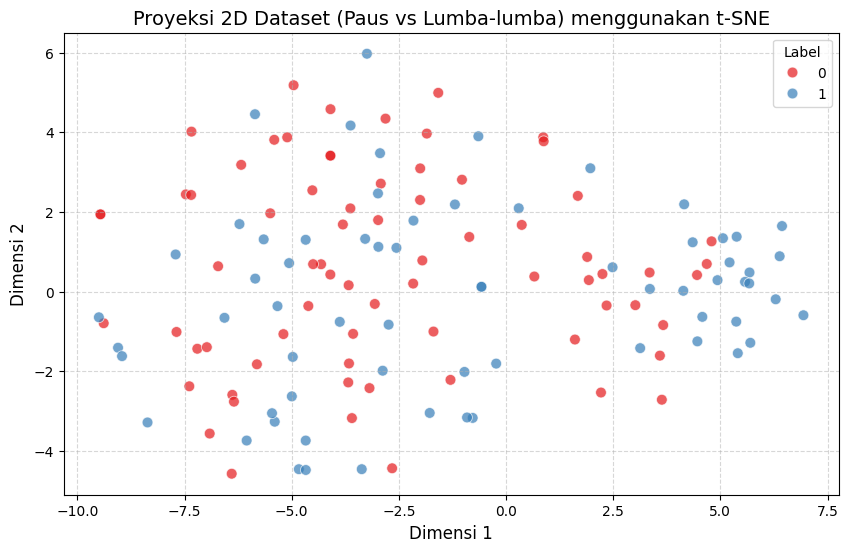

In [ ]:
plt.figure(figsize = (10 , 6))
sns.scatterplot(x = "t-SNE Dimensi 1" , y = "t-SNE Dimensi 2" , hue = "Label" , palette = "Set1" , data = tsne_df , legend = "full" , alpha = 0.7 , s = 60)
plt.title("Proyeksi 2D Dataset (Paus vs Lumba-lumba) menggunakan t-SNE" , fontsize = 14)
plt.xlabel("Dimensi 1" , fontsize = 12)
plt.ylabel("Dimensi 2" , fontsize = 12)
plt.grid(True , linestyle = "--" , alpha = 0.5)
plt.show()

Dilihat dari proyeksi 2D dataset menggunakan t-SNE, data tersebar sangat acak untuk kedua kelas. hal ini menyebabkan ketidakmungkinan untuk dibuat batas yang jelas baik secara linear maupun non-linear.

Karena t-SNE ini mengambil pola hanya dari segi warna secara tradisional atau dengan kata lain dalam nilai piksel mentah (visualnya saja), kedua hewan akan sangat sulit dibedakan. ini wajar karena kedua hewan memang sama-sama hidup di laut sehingga semua foto pasti berlatar warna biru.

Implikasi jauhnya, akan sangat sulit jika hanya menggunakan algoritma seperti KNN atau SVM yang memanfaatkan data nilai piksel mentah karena tidak menampilkan karakteristik apapun.

---
# 2. Data Cleaning and Preprocessing

Lakukan preprocessing yang diperlukan agar data siap digunakan. Setiap langkah harus disertai **justifikasi** yang merujuk pada temuan EDA.

### 2.1 [Wajib] Resizing dan Normalisasi Gambar

Lakukan *resizing* gambar ke dimensi yang konsisten (224×224 untuk AlexNet) dan normalisasi nilai piksel. Justifikasikan pilihan Anda berdasarkan distribusi fitur yang ditemukan di EDA.

In [ ]:
# Write your code here
# Define transform pipelines for training and validation/test
base_transform = transforms.Compose([
    transforms.Resize((224 , 224)) ,
    transforms.ToTensor() ,
    transforms.Normalize(mean = [0.485 , 0.456 , 0.406] , std = [0.229 , 0.224 , 0.225])
])

Justification: Transformasi gambar berupa resize menjadi 224*224 adalah standar untuk konsistensi pada AlexNet, sedangkan angka normalisasi dipilih berdasarkan standar dari dataset ImageNet. Source : https://docs.pytorch.org/vision/stable/transforms.html

### 2.2 [Wajib] Pembagian Dataset

Split the dataset into **training set, validation set, and test set** with reasonable proportions. This is done before augmentation to **avoid data leakage**.

In [ ]:
# Write your code here
# Split into train, val, test
train_val_df , test_df = train_test_split(train_df , test_size = 0.15 , random_state = SEED , stratify = train_df["Label"])
train_split_df , val_df = train_test_split(train_val_df , test_size = 0.176 , random_state = SEED , stratify = train_val_df["Label"])
print(f"Train : {len(train_split_df)} , Val : {len(val_df)} , Test : {len(test_df)}")

Train : 96 , Val : 21 , Test : 21


Justification: Pembagian dataset menjadi train set, val set, dan test set menjadi penting untuk melatih model agar data yang digunakan untuk training berbeda dengan validasi dan test. Angka pembagian menggunakan template yang telah disediakan.

### 2.3 [Opsional] Preprocessing Tambahan

Langkah tambahan jika relevan berdasarkan EDA:
- Penanganan outlier jika ditemukan gambar yang rusak, tidak relevan, atau memiliki pencahayaan ekstrem.
- Data augmentation seperti *horizontal flip*, rotasi, atau *brightness adjustment* untuk memperkaya variasi dataset.

In [ ]:
# Write your code here
train_transform = transforms.Compose([
    transforms.Resize((224 , 224)) ,
    transforms.RandomHorizontalFlip(p = 0.5) ,
    transforms.RandomRotation(15) ,
    transforms.ToTensor() ,
    transforms.Normalize(mean = [0.485 , 0.456 , 0.406] , std = [0.229 , 0.224 , 0.225])
])

Justification: Menambahkan proses augmentasi bertujuan untuk memperkaya variasi dataset dengan opsi gambar yang lebih banyak untuk data training. Angka normalisasi mengikuti standar yang dipakai di base transform untuk kesederhanaan, sedangkan angka rotasi dan flip dipilih angka yang umum dan wajar terjadi.

### Helper: Custom Dataset Class

In [ ]:
# Define a custom PyTorch Dataset
# Write your code here
class CustomImageDataset(Dataset) :
    def __init__(self , data , img_dir , transform = None) :
        self.img_labels = data.reset_index(drop = True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self) :
        return len(self.img_labels)

    def __getitem__(self , idx) :
        file_id = str(self.img_labels.iloc[idx , 0])
        img_path = os.path.join(self.img_dir , file_id)
        image = Image.open(img_path).convert("RGB")
        label = self.img_labels.iloc[idx , 1]
        if (self.transform) :
            image = self.transform(image)
        return (image , label)

train_dataset = CustomImageDataset(data = train_split_df , img_dir = TRAIN_IMG_DIR , transform = train_transform)
val_dataset = CustomImageDataset(data = val_df , img_dir = TRAIN_IMG_DIR , transform = base_transform)
test_dataset = CustomImageDataset(data = test_df , img_dir = TRAIN_IMG_DIR , transform = base_transform)
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True)
val_loader = DataLoader(val_dataset , batch_size = 32 , shuffle = False)
test_loader = DataLoader(test_dataset , batch_size = 32 , shuffle = False)

### Helper: Training and Evaluation Functions

In [ ]:
# Define training loop, evaluation function, and plotting utilities
# Write your code here
def train_model(model , train_loader , val_loader , criterion , optimizer , num_epochs = 15) :
    train_losses , val_losses = [] , []
    train_accs , val_accs = [] , []

    for (epoch) in (range(num_epochs)) :
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct , total = 0 , 0

        # Training Phase
        for (images , labels) in (train_loader) :
            images , labels = images.to(device) , labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs , labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _ , predicted = torch.max(outputs.data , 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        correct_val , total_val = 0 , 0
        with (torch.no_grad()) :
            for (images , labels) in (val_loader) :
                images , labels = images.to(device) , labels.to(device)
                outputs = model(images)
                loss = criterion(outputs , labels)
                val_loss += loss.item() * images.size(0)
                _ , predicted = torch.max(outputs.data , 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        # Recap Phase
        time_elapsed = time.time() - start_time
        print(f"Epoch [{epoch + 1}/{num_epochs}] ({time_elapsed:.0f}s) | Train Loss : {epoch_train_loss:.4f} - Acc : {epoch_train_acc:.4f} | Val Loss : {epoch_val_loss:.4f} - Acc : {epoch_val_acc:.4f}")

    return (train_losses , val_losses , train_accs , val_accs)

def evaluate_model(model , loader) :
    model.eval()
    y_true , y_pred = [] , []
    with torch.no_grad() :
        for (images , labels) in loader :
            images , labels = images.to(device) , labels.to(device)
            outputs = model(images)
            _ , predicted = torch.max(outputs , 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    return (y_true , y_pred)

def show_evaluation(model , loader , title = "Model") :
    y_true , y_pred = evaluate_model(model , loader)
    print(f"=== {title} — Classification Report ===")
    print(f"Macro F1-Score : {f1_score(y_true , y_pred , average = "macro"):.4f}")
    print(classification_report(y_true , y_pred))
    cm = confusion_matrix(y_true , y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap ="Blues")
    plt.title(title , fontweight = "bold")
    plt.show()

def compare_models(model_a , model_b , loader , title_a = "AlexNet" , title_b = "Pretrained") :
    y_true_a , y_pred_a = evaluate_model(model_a , loader)
    y_true_b , y_pred_b = evaluate_model(model_b , loader)
    for (title , y_true , y_pred) in [(title_a , y_true_a , y_pred_a) , (title_b , y_true_b , y_pred_b)] :
        print(f"=== {title} — Classification Report ===")
        print(f"Macro F1-Score : {f1_score(y_true , y_pred , average = "macro"):.4f}")
        print(classification_report(y_true , y_pred))
    cm_a = confusion_matrix(y_true_a , y_pred_a)
    cm_b = confusion_matrix(y_true_b , y_pred_b)
    fig , (ax1 , ax2) = plt.subplots(1 , 2 , figsize = (14 , 5))
    ConfusionMatrixDisplay(cm_a).plot(ax = ax1 , cmap = "Blues" , colorbar = False)
    ConfusionMatrixDisplay(cm_b).plot(ax = ax2 , cmap = "Blues" , colorbar = False)
    ax1.set_title(title_a , fontweight = "bold")
    ax2.set_title(title_b , fontweight = "bold")
    plt.suptitle("Confusion Matrix Comparison" , fontsize = 14)
    plt.tight_layout()
    plt.show()

def get_per_class_f1(model_eval , loader) :
    model_eval.eval()
    y_true , y_pred = [] , []
    with torch.no_grad():
        for (images , labels) in (loader) :
            images , labels = images.to(device) , labels.to(device)
            outputs = model_eval(images)
            _, predicted = torch.max(outputs , 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    return f1_score(y_true , y_pred , average = None)

def plot_training_history(history) :
    train_losses , val_losses , train_accs , val_accs = history
    fig , ax = plt.subplots(1 , 2 , figsize = (10 , 6))
    ax[0].plot(train_losses , label = "Train Loss" , color = "navy")
    ax[0].plot(val_losses, label = "Val Loss" , color = "cornflowerblue")
    ax[0].set_title("Loss Progression")
    ax[0].legend()
    ax[1].plot(train_accs , label = "Train Acc" , color = "navy")
    ax[1].plot(val_accs , label = "Val Acc" , color = "cornflowerblue")
    ax[1].set_title("Accuracy Progression")
    ax[1].legend()
    plt.show()

---
# 3. Modeling and Validation

Pada praktikum ini, Anda diminta mengimplementasikan dan membandingkan dua model CNN:
1. **AlexNet Scratch** — dibangun sendiri dari awal menggunakan PyTorch/TensorFlow.
2. **Pretrained Model + Finetuning** — menggunakan model yang telah dilatih pada dataset lain, kemudian dilakukan transfer learning ke dataset ini.

## 3.1 Model AlexNet (from Scratch)

Bangun model dengan arsitektur AlexNet dari awal menggunakan PyTorch atau TensorFlow, kemudian latih pada dataset yang telah disediakan.

In [ ]:
# Define AlexNet architecture from scratch
# Write your code here
class AlexNet(nn.Module) :
    def __init__(self , num_classes = 2) :
        super(AlexNet , self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels = 3 , out_channels = 64 , kernel_size = 11 , stride = 4 , padding = 2) ,
            nn.ReLU(inplace = True) ,
            nn.MaxPool2d(kernel_size = 3 , stride = 2) ,
            nn.Conv2d(in_channels = 64 , out_channels = 192 , kernel_size = 5 , padding = 2) ,
            nn.ReLU(inplace = True) ,
            nn.MaxPool2d(kernel_size = 3 , stride = 2) ,
            nn.Conv2d(in_channels = 192 , out_channels = 384 , kernel_size = 3 , padding = 1) ,
            nn.ReLU(inplace = True) ,
            nn.Conv2d(in_channels = 384 , out_channels = 256 , kernel_size = 3 , padding = 1) ,
            nn.ReLU(inplace = True) ,
            nn.Conv2d(in_channels = 256 , out_channels = 256 , kernel_size = 3 , padding = 1) ,
            nn.ReLU(inplace = True) ,
            nn.MaxPool2d(kernel_size = 3 , stride = 2)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6 , 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p = 0.5) ,
            nn.Linear(256 * 6 * 6 , 4096) ,
            nn.ReLU(inplace = True) ,
            nn.Dropout(p = 0.5) ,
            nn.Linear(4096 , 4096) ,
            nn.ReLU(inplace = True) ,
            nn.Linear(4096 , num_classes)
        )

    def forward(self , x) :
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x , 1)
        x = self.classifier(x)
        return x

# Define Model
alexnet_model = AlexNet(num_classes = 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(alexnet_model.parameters() , lr = 5e-4)

In [ ]:
# Print AlexNet Scratch architecture and total parameter count
# Write your code here
total_params = sum(p.numel() for (p) in (alexnet_model.parameters()))
trainable_params = sum(p.numel() for (p) in (alexnet_model.parameters()) if (p.requires_grad))
print(alexnet_model)
print(f"Total Parameters : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
# Train AlexNet Scratch
# Write your code here
history_alexnet = train_model(alexnet_model , train_loader , val_loader , criterion , optimizer , num_epochs = 15)

Epoch [1/15] (5s) | Train Loss : 0.7760 - Acc : 0.4583 | Val Loss : 0.6999 - Acc : 0.4762
Epoch [2/15] (5s) | Train Loss : 0.7003 - Acc : 0.5000 | Val Loss : 0.6913 - Acc : 0.5238
Epoch [3/15] (8s) | Train Loss : 0.6921 - Acc : 0.5208 | Val Loss : 0.6868 - Acc : 0.5238
Epoch [4/15] (7s) | Train Loss : 0.6902 - Acc : 0.5417 | Val Loss : 0.6761 - Acc : 0.5714
Epoch [5/15] (6s) | Train Loss : 0.6669 - Acc : 0.5938 | Val Loss : 0.6172 - Acc : 0.6667
Epoch [6/15] (4s) | Train Loss : 0.5896 - Acc : 0.7396 | Val Loss : 0.6854 - Acc : 0.6190
Epoch [7/15] (5s) | Train Loss : 0.5920 - Acc : 0.7188 | Val Loss : 0.6538 - Acc : 0.6667
Epoch [8/15] (5s) | Train Loss : 0.6503 - Acc : 0.6562 | Val Loss : 0.6233 - Acc : 0.5238
Epoch [9/15] (4s) | Train Loss : 0.6126 - Acc : 0.6250 | Val Loss : 0.6919 - Acc : 0.5714
Epoch [10/15] (4s) | Train Loss : 0.5822 - Acc : 0.6458 | Val Loss : 0.6208 - Acc : 0.6190
Epoch [11/15] (5s) | Train Loss : 0.5748 - Acc : 0.8125 | Val Loss : 0.5874 - Acc : 0.6667
Epoch [1

#### Evaluasi AlexNet Scratch

Required:
1. Macro F1-Score dan akurasi keseluruhan pada test set
2. Confusion matrix heatmap
3. Per-class F1-score
4. Training loss dan validation loss curve per epoch dalam satu grafik
5. Analisis overfitting / underfitting berdasarkan learning curve

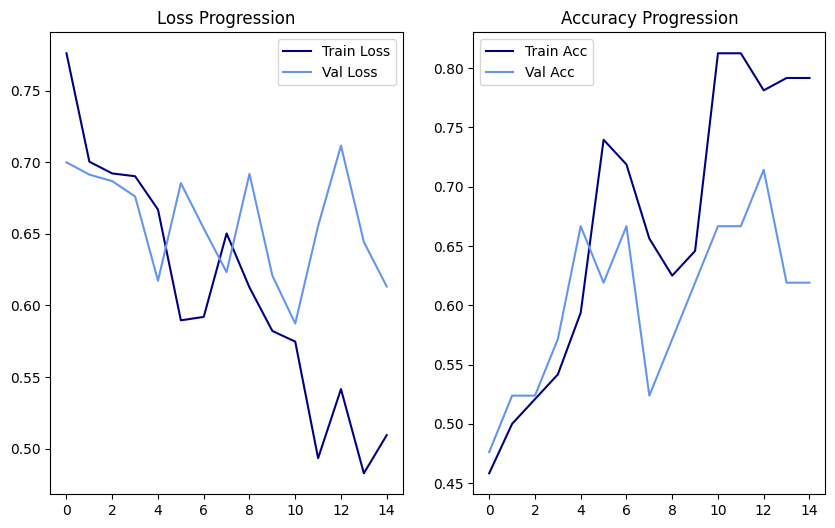

In [ ]:
# AlexNet Scratch: Loss curves
# Write your code here
plot_training_history(history_alexnet)

=== AlexNet Model — Classification Report ===
Macro F1-Score : 0.6182
              precision    recall  f1-score   support

           0       0.67      0.55      0.60        11
           1       0.58      0.70      0.64        10

    accuracy                           0.62        21
   macro avg       0.62      0.62      0.62        21
weighted avg       0.63      0.62      0.62        21



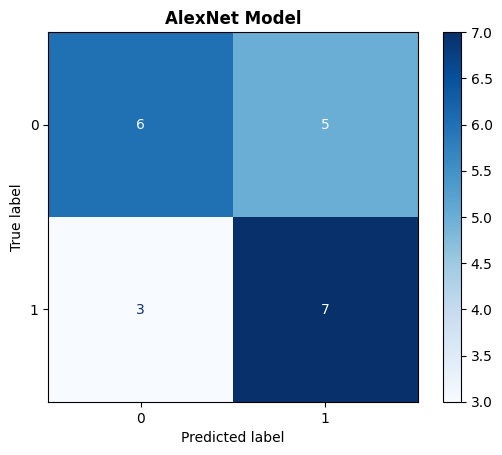

In [ ]:
# AlexNet Scratch: Test set evaluation
# Write your code here
show_evaluation(alexnet_model , val_loader , title = "AlexNet Model")

**Analisis AlexNet Scratch (overfitting/underfitting):**

Berdasarkan hasil pengujian di atas, terlihat hasilnya cukup overfit. Hal ini terbukti dari perubahan loss dan accuracy yang sangat drastis sehingga model cenderung menghafal dan bukan belajar. Sumber penentuan konfigurasi model : https://github.com/pytorch/vision/blob/main/torchvision/models/alexnet.py

---
## 3.2 Pretrained Model + Finetuning (Transfer Learning)

Gunakan pretrained model yang di dalam arsitekturnya terdapat bagian CNN (contoh: ResNet, Inception, MobileNet, dll.), kemudian lakukan finetuning terhadap dataset ini.

**Ketentuan:**
- Pretrained model dibebaskan selama di dalam arsitekturnya terdapat bagian CNN.
- Sesuaikan layer output terakhir untuk klasifikasi biner (2 kelas).
- **Wajib sertakan justifikasi pilihan pretrained model.**

In [ ]:
# Load pretrained model and modify for binary classification
# Write your code here
pretrained_model = models.resnet18(pretrained = True)
for (param) in (pretrained_model.parameters()) :
    param.requires_grad = False
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Sequential(nn.Dropout(0.5) , nn.Linear(num_ftrs , 2))
pretrained_model = pretrained_model.to(device)

In [ ]:
# Print Pretrained Model architecture and total parameter count
# Write your code here
total_params = sum(p.numel() for (p) in (pretrained_model.parameters()))
trainable_params = sum(p.numel() for (p) in (pretrained_model.parameters()) if (p.requires_grad))
print(pretrained_model.fc)
print(f"Total Parameters : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)
Total Parameters : 11,177,538
Trainable Parameters : 1,026


**Justifikasi Pilihan Pretrained Model:**

Pretrained Model yang dipilih adalah ResNet18 karena ini berdasarkan template yang diberikan, selain itu arsitektur nya yang baik mencegahnya dari overfitting ataupun underfitting. Strategi freezing dilakukan pada seluruh layar konvolusi dan hanya training layer untuk binary classification.

In [ ]:
# Train Pretrained Model
# Write your code here
# Use the same NUM_EPOCHS and criterion as AlexNet Scratch for fair comparison
criterion = nn.CrossEntropyLoss()
optimizer_pretrained = optim.Adam(pretrained_model.fc.parameters() , lr = 5e-3)
history_pretrained = train_model(pretrained_model , train_loader , val_loader , criterion , optimizer_pretrained , num_epochs = 15)

Epoch [1/15] (6s) | Train Loss : 0.9924 - Acc : 0.4896 | Val Loss : 0.6401 - Acc : 0.6190
Epoch [2/15] (5s) | Train Loss : 0.7293 - Acc : 0.5312 | Val Loss : 0.6329 - Acc : 0.5714
Epoch [3/15] (4s) | Train Loss : 0.5942 - Acc : 0.6771 | Val Loss : 0.5913 - Acc : 0.6190
Epoch [4/15] (7s) | Train Loss : 0.5809 - Acc : 0.6667 | Val Loss : 0.6467 - Acc : 0.6190
Epoch [5/15] (6s) | Train Loss : 0.5936 - Acc : 0.7188 | Val Loss : 0.4880 - Acc : 0.7619
Epoch [6/15] (8s) | Train Loss : 0.4298 - Acc : 0.8021 | Val Loss : 0.6449 - Acc : 0.6190
Epoch [7/15] (4s) | Train Loss : 0.4858 - Acc : 0.7917 | Val Loss : 0.5255 - Acc : 0.7143
Epoch [8/15] (5s) | Train Loss : 0.3895 - Acc : 0.7708 | Val Loss : 0.4037 - Acc : 0.8571
Epoch [9/15] (4s) | Train Loss : 0.5093 - Acc : 0.7396 | Val Loss : 0.4062 - Acc : 0.9048
Epoch [10/15] (4s) | Train Loss : 0.4548 - Acc : 0.8229 | Val Loss : 0.5590 - Acc : 0.7143
Epoch [11/15] (6s) | Train Loss : 0.4484 - Acc : 0.8125 | Val Loss : 0.4012 - Acc : 0.8095
Epoch [1

#### Evaluasi Pretrained Model

Required:
1. Macro F1-Score dan akurasi keseluruhan pada test set
2. Confusion matrix heatmap
3. Per-class F1-score
4. Training loss dan validation loss curve per epoch dalam satu grafik
5. Analisis overfitting / underfitting berdasarkan learning curve

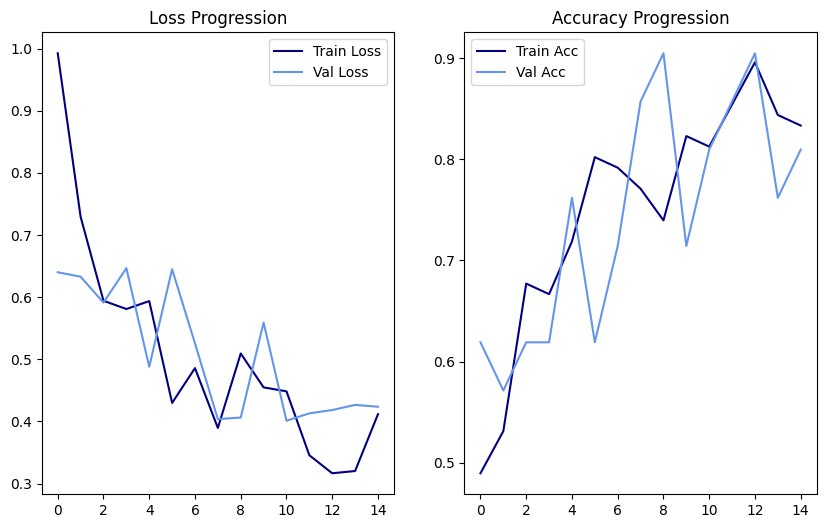

In [ ]:
# Pretrained Model: Loss curves
# Write your code here
plot_training_history(history_pretrained)

=== Pretrained Model — Classification Report ===
Macro F1-Score : 0.8091
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        11
           1       0.80      0.80      0.80        10

    accuracy                           0.81        21
   macro avg       0.81      0.81      0.81        21
weighted avg       0.81      0.81      0.81        21



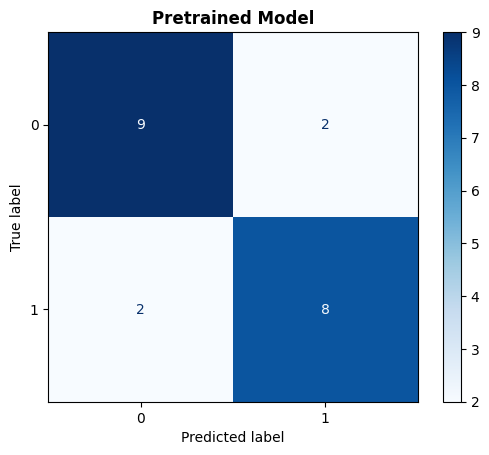

In [ ]:
# Pretrained Model: Test set evaluation
# Write your code here
show_evaluation(pretrained_model , val_loader , title = "Pretrained Model")

**Analisis Pretrained Model (overfitting/underfitting):**

Berdasarkan hasil pengujian di atas, terlihat hasilnya cukup pas, tidak overfit, dan tidak underfit. Hal ini terbukti dari perubahan loss dan accuracy yang perlahan sehingga model cenderung belajar dan bukan menghafal.

---
# 4. Analysis

Setelah seluruh model selesai dibangun dan dievaluasi, lakukan analisis perbandingan menyeluruh. Analisis yang **dinilai baik** bukan hanya melaporkan angka, tetapi **menginterpretasikan** apa yang menyebabkan perbedaan tersebut.

### 4.1 Tabel Perbandingan

| Model | Macro F1 | Accuracy | Est. Total Parameters |
|---|---|---|---|
| AlexNet Scratch | 0.6182 | 0.62 | 57,012,034 |
| Pretrained Model (ResNet18) | 0.8091 | 0.81 | 1,026 |

**Total Trainable Parameter**

Dengan menggunakan teknik Transfer Learning (membekukan fitur dasar) pada ResNet18 yaitu *param.requires_grad = False*, parameter yang dilatih hanyalah lapisan nn.Linear pada yang ada di bagian akhir lapisan ResNet. Lapisan terakhir ResNet-18 mengeluarkan 512 fitur (num_ftrs) yang dihubungkan ke 2 kelas (Paus dan Lumba-lumba).
Maka perhitungannya: (512 bobot x 2 output) + 2 bias = 1024 + 2 = 1.026 parameter.

Sementara itu, pada AlexNet, setelah gambar diproses oleh lapisan konvolusi, hasilnya diratakan (flatten) dan dihubungkan ke lapisan berisi 4096 neuron, lalu ke 4096 neuron lagi.
Menghubungkan puluhan ribu titik ke 4096 titik lainnya inilah yang membutuhkan puluhan juta bobot.

### 4.2 Confusion Matrix Perbandingan

Confusion matrix kedua model ditampilkan **berdampingan** untuk memudahkan perbandingan visual dalam mendeteksi kesalahan klasifikasi antara lumba-lumba dan paus.

=== AlexNet — Classification Report ===
Macro F1-Score : 0.6182
              precision    recall  f1-score   support

           0       0.67      0.55      0.60        11
           1       0.58      0.70      0.64        10

    accuracy                           0.62        21
   macro avg       0.62      0.62      0.62        21
weighted avg       0.63      0.62      0.62        21

=== Pretrained — Classification Report ===
Macro F1-Score : 0.8091
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        11
           1       0.80      0.80      0.80        10

    accuracy                           0.81        21
   macro avg       0.81      0.81      0.81        21
weighted avg       0.81      0.81      0.81        21



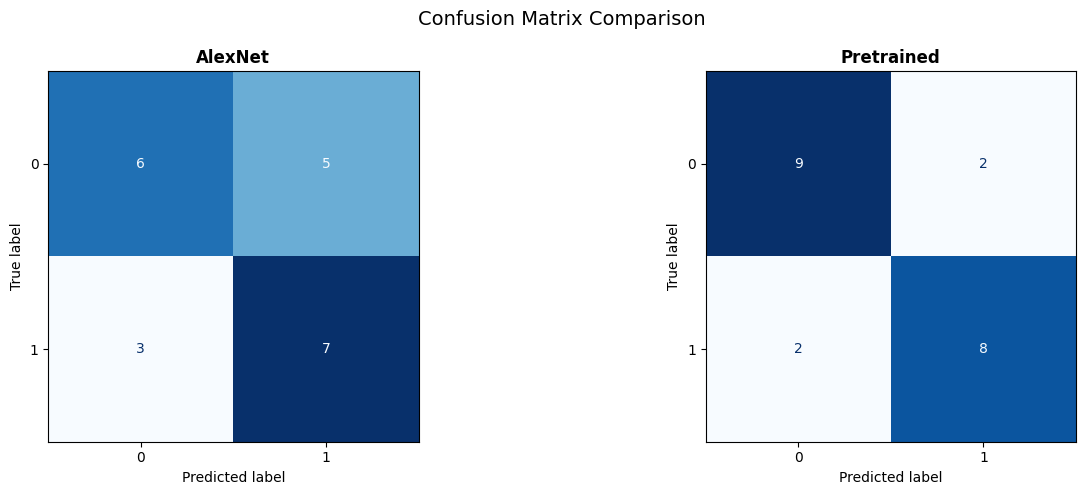

In [ ]:
# Plot two confusion matrices side-by-side
# Write your code here
compare_models(alexnet_model , pretrained_model , val_loader)

- Berdasarkan performa, selisihnya cukup jauh (+- 20%). hal ini disebabkan oleh penggunaan teknik Transfer learning (ResNet18) yang tidak perlu belajar mengekstraksi fitur dasar dari nol pada AlexNet karena sudah memiliki pengetahuan dasar dari dataset ImageNet.

- Dari segi prediksi, ada indikasi bias pada AlexNet karena Recall-nya cukup rendah (0,55) pada kelas lumba-lumba sehingga gagal memprediksi separuh dari total gambar (False Negatives tinggi). Begitu juga dengan Paus yang mengindikasikan banyaknya tebakan Kelas 1 yang sebenarnya salah (False Positives).

### 4.3 Per-Class F1-Score Comparison

Per-class F1-score kedua model dalam satu grafik batang. Kelas mana yang paling diuntungkan saat beralih dari AlexNet *scratch* ke *pretrained model*? Mengapa?

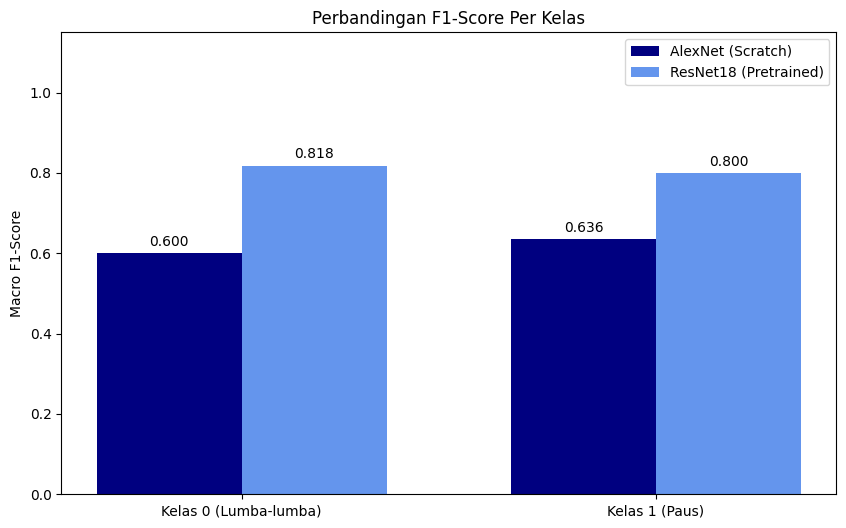

In [ ]:
# Grouped bar chart of per-class F1-scores
# Write your code here
f1_alexnet = get_per_class_f1(alexnet_model , val_loader)
f1_pretrained = get_per_class_f1(pretrained_model , val_loader)
classes = ["Kelas 0 (Lumba-lumba)" , "Kelas 1 (Paus)"]
x = np.arange(len(classes))
width = 0.35
fig , ax = plt.subplots(figsize = (10 , 6))
rects1 = ax.bar(x - width / 2 , f1_alexnet , width , label = "AlexNet (Scratch)" , color = "navy")
rects2 = ax.bar(x + width / 2 , f1_pretrained , width , label = "ResNet18 (Pretrained)" , color = "cornflowerblue")
ax.set_ylabel("Macro F1-Score")
ax.set_title("Perbandingan F1-Score Per Kelas")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(loc = "upper right")
ax.set_ylim([0 , 1.15])
ax.bar_label(rects1 , padding = 3 , fmt = "%.3f")
ax.bar_label(rects2 , padding = 3 , fmt = "%.3f")
plt.show()

Sebenarnya dari histogram di atas, tidak kelas yang lebih diuntungkan karena bagi kedua kelas, peralihan dari AlexNet ke ResNet sama-sama menguntungkan. Kembali lagi, ini adalah implikasi dari teknik Transfer Learning pada ResNet18.

### 4.4 Analisis Bias-Variance

Analisis bias-variance: model mana yang menunjukkan underfitting? Overfitting? Gunakan learning curve sebagai bukti.

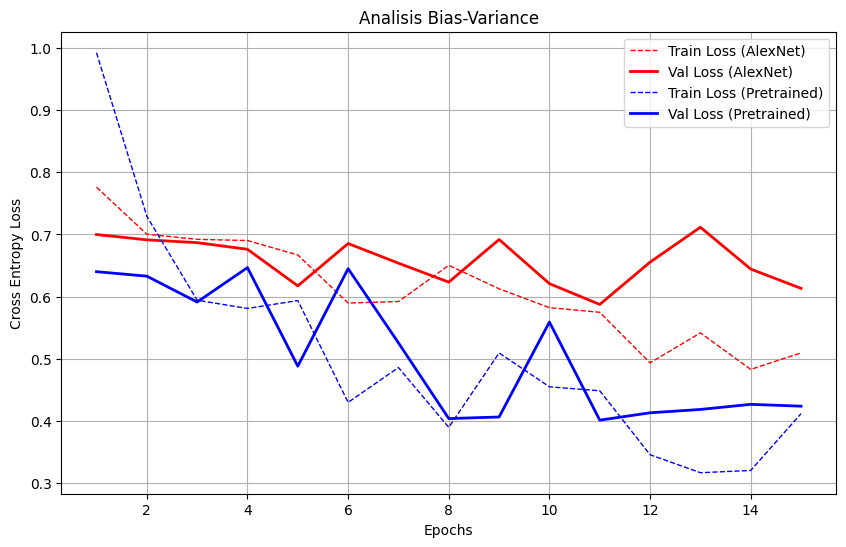

In [ ]:
# Plot both loss curves in a single figure for easy comparison
# Write your code here
train_loss_alexnet , val_loss_alexnet , _ ,  _ = history_alexnet
train_loss_pretrained , val_loss_pretrained , _ , _ = history_pretrained
epochs_alexnet = range(1 , len(train_loss_alexnet) + 1)
epochs_pretrained = range(1 , len(train_loss_pretrained) + 1)
plt.figure(figsize = (10 , 6))
plt.plot(epochs_alexnet , train_loss_alexnet , color = "red" , linestyle = "--" , linewidth = 1 , label = "Train Loss (AlexNet)")
plt.plot(epochs_alexnet , val_loss_alexnet , color = "red" , linestyle = "-" , linewidth = 2 , label = "Val Loss (AlexNet)")
plt.plot(epochs_pretrained , train_loss_pretrained , color = "blue" , linestyle = "--" , linewidth = 1 , label = "Train Loss (Pretrained)")
plt.plot(epochs_pretrained , val_loss_pretrained , color = "blue" , linestyle = "-" , linewidth = 2 , label = "Val Loss (Pretrained)")
plt.title("Analisis Bias-Variance")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

- AlexNet : terindikasi overfitting karena terlihat mulai pada epoch ke-7 hingga akhir, Train Loss terus menurun tetapi sangat kontras dengan Val Loss-nya yang justru masih sangat fluktuatif. kemungkinan ini disebabkan oleh model yang terlalu menghafal noise dan/atau detail-detail yang lebih spesifik sehingga gagal untuk mampu menggeneralisasi data baru.

- Pretrained : terlihat seimbang, tidak overfitting tetapi tidak juga underfitting karena baik Train Loss maupun Val Loss, keduanya sama-sama cenderung turun seiring bertambahnya epoch walaupun tetap fluktuatif.

### 4.5 Trade-off: Transfer Learning vs. Training from Scratch

Apakah penggunaan *transfer learning* (*pre-trained model*) selalu memberikan performa lebih baik pada dataset ini? Diskusikan *trade-off* antara kompleksitas model, waktu *training*, dan akurasi yang didapat.

Sejauh pengamatan dan beberapa kali percobaan yang dilakukan menggunakan berbagai kombinasi parameter, teknik transfer learning **selalu** memberikan performa lebih baik **pada dataset ini**. Namun, memang dari segi kompleksitas model jelas ResNet jauh lebih kompleks karena menggunakan 18 layer (dengan Residual Blocks).

Sementara itu, dari segi waktu AlexNet cukup memakan waktu yang lama untuk training per epochnya dan akan sangat jauh jika dibandingkan dengan ResNet yang berjalan sangat cepat.

---
# 5. Insights

Untuk setiap tahap yang dilakukan, sebutkan insight yang didapatkan selama pengerjaan praktikum. Insight yang dimaksud adalah analisis dan juga argumen pendukung terhadap setiap tahap yang dilakukan.

### 5.1 Insight EDA

#### *5.1.1 Distribusi Kelas*
Berdasarkan eksplorasi dan evaluasi training (dengan perbandingan 72:66) serta validation data (dengan support 11 dan 10), dataset menunjukkan distribusi yang cukup seimbang (balanced). Keseimbangan ini meminimalisir risiko kejadian ketika akurasinya sangat tinggi tetapi tidak cukup prediktif akibat class imbalance.

#### *5.1.2 Variansi Dimensi dan Aspect Ratio*
Terdapat variasi yang signifikan pada resolusi dan aspect ratio gambar. Mayoritas gambar berbentuk persegi panjang. Agar gambar tidak kehilangan fitur/karakteristiknya, resize gambar (karena AlexNet butuh dimensi 224x224) dilakukan dengan menambah padding pada bagian yang lebih pendek.

#### *5.1.3 Intensitas Piksel (RGB)*
Dari ketiga warna, sebenarnya tidak ada perbedaan cukup signifikan kecuali pada rentang nilai piksel 200 - 250 pada warna biru yang sangat kontras dari kedua kelas. Meski demikian, akan tetap sulit untuk mengandalkan fitur intensitas warna karena memang hampir semua gambarnya berlatar air.

#### *5.1.4 Proyeksi 2D (t-SNE)*
Dari plot, dapat dilihat bahwa persebaran data cukup merata sehingga akan sulit jika melakukan klasifikasi menggunakan algoritma tradisional seperti SVM atau KNN karena tidak dapat membuat batas yang jelas baik secara linear maupun non-linear.

### 5.2 Insight Data Preprocessing

#### *5.2.1 Resize ke 224×224*
Karena EDA menunjukkan mayoritas gambar berbentuk persegi panjang dengan aspect ratio rata-rata 1.42, resize langsung ke 224×224 berpotensi mendistorsi proporsi objek (paus/lumba-lumba). Meski demikian, AlexNet dan ResNet memang mensyaratkan dimensi tetap, dan distorsi minor pada umumnya masih dapat ditoleransi oleh model CNN yang cukup dalam karena representasi fitur belajar secara hierarki.

#### *5.2.2 Normalisasi dengan Mean/Std ImageNet*
Normalisasi menggunakan mean=[0.485, 0.456, 0.406] dan std=[0.229, 0.224, 0.225] dipilih karena mengikuti standar ImageNet. Normalisasi ini juga membantu mempercepat konvergensi bagi AlexNet.

#### *5.2.3 Stratified Split (70/15/15)*
Pembagian dataset menggunakan stratify dilakukan untuk memastikan proporsi kelas tetap seimbang di setiap split serta mencegah salah satu split terlalu didominasi oleh satu kelas saja.

#### *5.2.4 Augmentasi hanya pada Training Set*
Augmentasi hanya diterapkan pada training set saja ini untuk menghindari data leakage serta memperkaya variasi data training agar model lebih robust dan bukan untuk mengubah distribusi data evaluasi.

### 5.3 Insight Modeling and Validation

#### *5.3.1 AlexNet from Scratch*
Indikasi overfitting terlihat jelas dari learning curve di mana training loss terus turun pasca epoch ke-7 sementara validation loss justru fluktuatif dan tidak membaik secara konsisten.

#### *5.3.2 ResNet18 Pretrained*
ResNet18 dengan freezing seluruh convolutional layer hanya melatih 1.026 parameter (lapisan classifier akhir). Meski trainable parameter-nya sangat sedikit, performanya jauh lebih baik (F1 ~0.81 vs ~0.62). Ini membuktikan bahwa fitur yang dipelajari dari ImageNet (tepi, tekstur, bentuk umum) cukup general untuk ditransfer ke domain klasifikasi mamalia laut, bahkan tanpa fine-tuning layer konvolusi sama sekali.

#### *5.3.3 Dampak Learning Rate terhadap Konvergensi*
AlexNet menggunakan lr=5e-4 dengan Adam sedangkan ResNet menggunakan lr=5e-3 karena ResNet hanya mengoptimasi satu lapisan kecil (lebih mudah konvergen dengan lr lebih besar), sementara AlexNet mengoptimasi seluruh jaringan yang lebih dalam sehingga perlu lr lebih kecil untuk stabilitas.

#### *5.3.4 Recall Rendah AlexNet pada Kelas Lumba-lumba*
Recall AlexNet yang rendah (0.55) pada kelas  (Lumba-lumba) mengindikasikan model cenderung bias memprediksi Paus. Ini kemungkinan disebabkan oleh overfitting pada pola tertentu dari training set yang tidak ter-generalisasi dengan baik, bukan akibat class imbalance (karena distribusi sudah cukup seimbang berdasarkan EDA 1.1).

### 5.4 Insight Analysis

Secara umum ResNet-18 (pretrained) mencetak performa yang jauh lebih tinggi (F1-Score 81%) dibandingkan AlexNet (F1-Score 62%). Meski demikian Resnet, dengan menggunakan teknik Transfer Learning yang membekukan base layer, trainable parameternya hanya 1026 saja yang sangat sangat jauh jika dibandingkan dengan AlexNet.

Dari segi kurva loss, AlexNet overfitting sedangkan ResNet lebih seimbang walaupun tetap fluktiatif. Selain itu, karena datanya seimbang, tidak ada kelas yang lebih diuntungkan ketika peralihan dari AlexNet ke ResNet.

---
# 6. Submisi Kaggle

**Submisi dibatasi 20 kali. Submisi final harus *reproducible*.**

Format penamaan kelompok di Kaggle: `Kelas_NomorKelompok_NamaKelompok` (Contoh: K1_99_gAIB21)

In [ ]:
# Load Kaggle test data
# Write your code here
test_df = pd.read_csv(os.path.join(BASE_LOCAL_PATH , "test.csv"))
print(f"Kaggle Test Samples : {len(test_df)}")
test_df.head()

Kaggle Test Samples : 35


,File_ID,Label
0,5f8818ba-b41c-4a4c-adb0-fcfecc08028e,0
1,77591aa1-5126-420a-ab44-ccbee2f7ed4a,0
2,8ce73dcf-a46f-4f0e-a210-f817f236428c,0
3,3f70726a-0989-4b6b-867a-70e300132aa0,0
4,6a6ffa77-fb3c-4320-bce9-e12a4d8b6006,0


In [ ]:
# Create test DataLoader with the same preprocessing pipeline
# Write your code here
class TestImageDataset(Dataset) :
    def __init__(self , csv_file , img_dir , transform = None) :
        self.img_labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.file_map = {os.path.splitext(f)[0]: f for (f) in (os.listdir(img_dir)) if (os.path.isfile(os.path.join(img_dir, f)))}

    def __len__(self) :
        return len(self.img_labels)

    def __getitem__(self , idx) :
        img_name = str(self.img_labels.iloc[idx , 0])
        real_filename = self.file_map[img_name]
        img_path = os.path.join(self.img_dir , real_filename)
        image = Image.open(img_path).convert("RGB")
        if (self.transform) :
            image = self.transform(image)
        return (image , img_name)

test_dataset = TestImageDataset(csv_file = TEST_CSV , img_dir = TEST_IMG_DIR , transform = base_transform)
test_loader = DataLoader(test_dataset , batch_size = 32 , shuffle = False)

In [ ]:
# Generate predictions using the best model
# Write your code here
best_model = pretrained_model
best_model.eval()
best_model.to(device)
test_predictions = []
test_ids = []
with (torch.no_grad()) :
    for (images , img_names) in (test_loader) :
        images = images.to(device)
        outputs = best_model(images)
        _ , predicted = torch.max(outputs , 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_ids.extend(img_names)

In [ ]:
# Create submission CSV
# Write your code here
submission = pd.DataFrame({"File_ID" : test_ids , "Label" : test_predictions})
submission.to_csv("K1_15_RaihanHanif_Submission.csv" , index = False)
print(f"Submission Shape : {submission.shape}")
submission.head(10)

Submission Shape : (35, 2)


,File_ID,Label
0,5f8818ba-b41c-4a4c-adb0-fcfecc08028e,0
1,77591aa1-5126-420a-ab44-ccbee2f7ed4a,1
2,8ce73dcf-a46f-4f0e-a210-f817f236428c,0
3,3f70726a-0989-4b6b-867a-70e300132aa0,0
4,6a6ffa77-fb3c-4320-bce9-e12a4d8b6006,0
5,34e3c78d-5e61-481d-b6b6-84627da046b7,0
6,4a96a06e-5132-457a-9871-c3c0b5fa8f1e,1
7,3d1d423b-b014-4aff-854f-90d148977262,1
8,9bd9ac53-71ab-4780-8fcd-b189a867299b,0
9,18182b53-e1e5-4931-b20b-541075059a9b,1


Mangat yak gess!

\- Asisten